# L96 benchmark — analysis-then-forecast across 10 Lyapunov times

Every method assimilates obs on the 0.5-time-unit window then is
free-forecast for 4.5 more time units (10 L96 Lyapunov times
total). The Hovmöller plots and the RMSE(t) trace below are
directly comparable to PyDA's L96 EnKF demo.

In [1]:
from __future__ import annotations

import time

import equinox as eqx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import optax
import vardax as vdx

from assimilation import (
    Lorenz96Forward,
    assemble_full_trajectory,
    assim_batch,
    compare,
    generate_l96_problem,
    run_method,
)

## 1. Shared problem

In [2]:
prob = generate_l96_problem(key=jax.random.PRNGKey(0))
batch = assim_batch(prob)
fwd = Lorenz96Forward(K=prob.K, F=prob.F, dt=prob.dt)
H_full = lx.IdentityLinearOperator(
    jax.ShapeDtypeStruct(prob.prior_mean.shape, jnp.float32)
)
H_state = lx.IdentityLinearOperator(jax.ShapeDtypeStruct((prob.K,), jnp.float32))
t_axis = jnp.arange(prob.T_total_plus_1) * prob.dt
print(f"K={prob.K}, T_assim={prob.T_assim}, T_total={prob.T_total}")
print(f"obs in assim window: {int(prob.mask.sum())} scalars")

K=40, T_assim=50, T_total=250
obs in assim window: 110 scalars


## 2. Classical methods

In [3]:
oi = vdx.OptimalInterpolation(
    obs_op=vdx.LinearObs(H_mat=H_full),
    prior_mean=prob.prior_mean, prior_cov_op=prob.B_op, obs_cov_op=prob.R_op,
)
three = vdx.ThreeDVar(
    obs_op=vdx.LinearObs(H_mat=H_full),
    prior_mean=prob.prior_mean, prior_cov_op=prob.B_op, obs_cov_op=prob.R_op,
    max_steps=1000,
)
strong = vdx.StrongFourDVar(
    forward=fwd, obs_op=vdx.LinearObs(H_mat=H_state),
    prior_mean=prob.prior_mean_state, prior_cov_op=prob.B_op_state,
    obs_cov_op=prob.R_op_state, max_steps=2000,
)
inc = vdx.IncrementalFourDVar(
    forward=fwd, obs_op=vdx.LinearObs(H_mat=H_state),
    prior_mean=prob.prior_mean_state, prior_cov_op=prob.B_op_state,
    obs_cov_op=prob.R_op_state,
    config=vdx.IncrementalConfig(n_outer=4, n_inner=200,
                                 cg_atol=1e-3, cg_rtol=1e-3),
)

results = [
    run_method("oi",
               lambda: assemble_full_trajectory(oi(batch)[0], prob, fwd), prob),
    run_method("3dvar",
               lambda: assemble_full_trajectory(three(batch)[0], prob, fwd), prob),
    run_method("strong_4dvar",
               lambda: assemble_full_trajectory(strong(batch)[0], prob, fwd), prob),
    run_method("incremental_4dvar",
               lambda: assemble_full_trajectory(inc(batch)[0], prob, fwd), prob),
]
for r in results:
    print(f"{r.name:20s} assim={r.rmse_assim:7.3f}  "
          f"forecast={r.rmse_forecast:7.3f}  total={r.rmse_total:7.3f}")

oi                   assim=  3.925  forecast=  4.212  total=  4.156
3dvar                assim=  3.925  forecast=  4.212  total=  4.156
strong_4dvar         assim=  3.744  forecast=  4.142  total=  4.064
incremental_4dvar    assim=  4.629  forecast=  5.121  total=  5.025


## 3. Learned methods

In [4]:
def make_pair(k):
    p = generate_l96_problem(key=k)
    return p.obs, p.mask, p.truth[: prob.T_assim_plus_1]


# FourDVarNet
key = jax.random.PRNGKey(0)
fvn = vdx.FourDVarNet1D(
    state_dim=prob.K, n_time=prob.T_assim_plus_1,
    latent_dim=32, hidden_dim=64, n_solver_steps=8, key=key,
)
fvn_keys = jax.random.split(jax.random.PRNGKey(1), 64)
obs_train, mask_train, truth_train = jax.vmap(make_pair)(fvn_keys)
fvn_batch = vdx.Batch1D(input=obs_train, mask=mask_train, target=truth_train)
fvn_opt = optax.adam(5e-3)
fvn_opt_state = fvn_opt.init(eqx.filter(fvn, eqx.is_array))
t0 = time.perf_counter()
for _ in range(500):
    fvn, fvn_opt_state, _ = vdx.train_step(fvn, fvn_batch, fvn_opt, fvn_opt_state)
fvn_train_time = time.perf_counter() - t0

results.append(run_method(
    "fourdvarnet",
    lambda: assemble_full_trajectory(fvn(batch)[0], prob, fwd),
    prob, train_time_s=fvn_train_time,
))
print(f"FourDVarNet train: {fvn_train_time:.1f}s, "
      f"rmse_forecast={results[-1].rmse_forecast:.3f}")

# Amortized
k_enc, k_head = jax.random.split(jax.random.PRNGKey(0))
amort = vdx.AmortizedPosterior(
    encoder=vdx.MLPObsEncoder(
        input_size=prob.T_assim_plus_1 * prob.K, context_dim=96,
        hidden_dim=256, depth=2, key=k_enc,
    ),
    head=vdx.RegressionHead(
        context_dim=96, state_shape=(prob.T_assim_plus_1, prob.K),
        hidden_dim=256, depth=2, key=k_head,
    ),
    config=vdx.AmortizedConfig(head_type="regression"),
)
am_keys = jax.random.split(jax.random.PRNGKey(2), 128)
obs_train, mask_train, truth_train = jax.vmap(make_pair)(am_keys)
am_batch = vdx.Batch1D(input=obs_train, mask=mask_train, target=truth_train)
am_opt = optax.adam(3e-3)
am_opt_state = am_opt.init(eqx.filter(amort, eqx.is_array))
t0 = time.perf_counter()
for _ in range(500):
    amort, am_opt_state, _ = vdx.amortized_train_step(
        amort, am_batch, am_opt, am_opt_state,
    )
am_train_time = time.perf_counter() - t0

results.append(run_method(
    "amortized",
    lambda: assemble_full_trajectory(amort(batch)[0], prob, fwd),
    prob, train_time_s=am_train_time,
))
print(f"Amortized train: {am_train_time:.1f}s, "
      f"rmse_forecast={results[-1].rmse_forecast:.3f}")

FourDVarNet train: 100.3s, rmse_forecast=4.733


Amortized train: 7.8s, rmse_forecast=4.481


## 4. Comparison table

In [5]:
table = compare(*results).sort_values("rmse_forecast")
table

,rmse_total,rmse_assim,rmse_forecast,rmse_min,rmse_median,rmse_max,runtime_ms,train_time_s
strong_4dvar,4.064315,3.743901,4.142056,1.686522,3.584424,7.248893,2641.426968,NaN
oi,4.155501,3.925395,4.212167,2.450513,3.806235,7.151021,615.605542,NaN
3dvar,4.155501,3.925395,4.212167,2.450513,3.806235,7.151022,1376.860088,NaN
amortized,4.232339,3.068543,4.481000,2.384618,4.140446,6.205668,204.666203,7.814268
fourdvarnet,4.461411,3.181860,4.732660,1.835591,4.334981,6.319676,392.063432,100.279530
incremental_4dvar,5.024750,4.629125,5.120746,2.026871,4.561325,8.896461,12132.669611,NaN


## 5. Hovmöller — truth, then each method

Each panel is a (time × grid) Hovmöller diagram. Methods with
good $x_0$ recovery produce panels that look identical to the
truth across the full window; bad analyses give panels that
diverge from truth after a Lyapunov time.

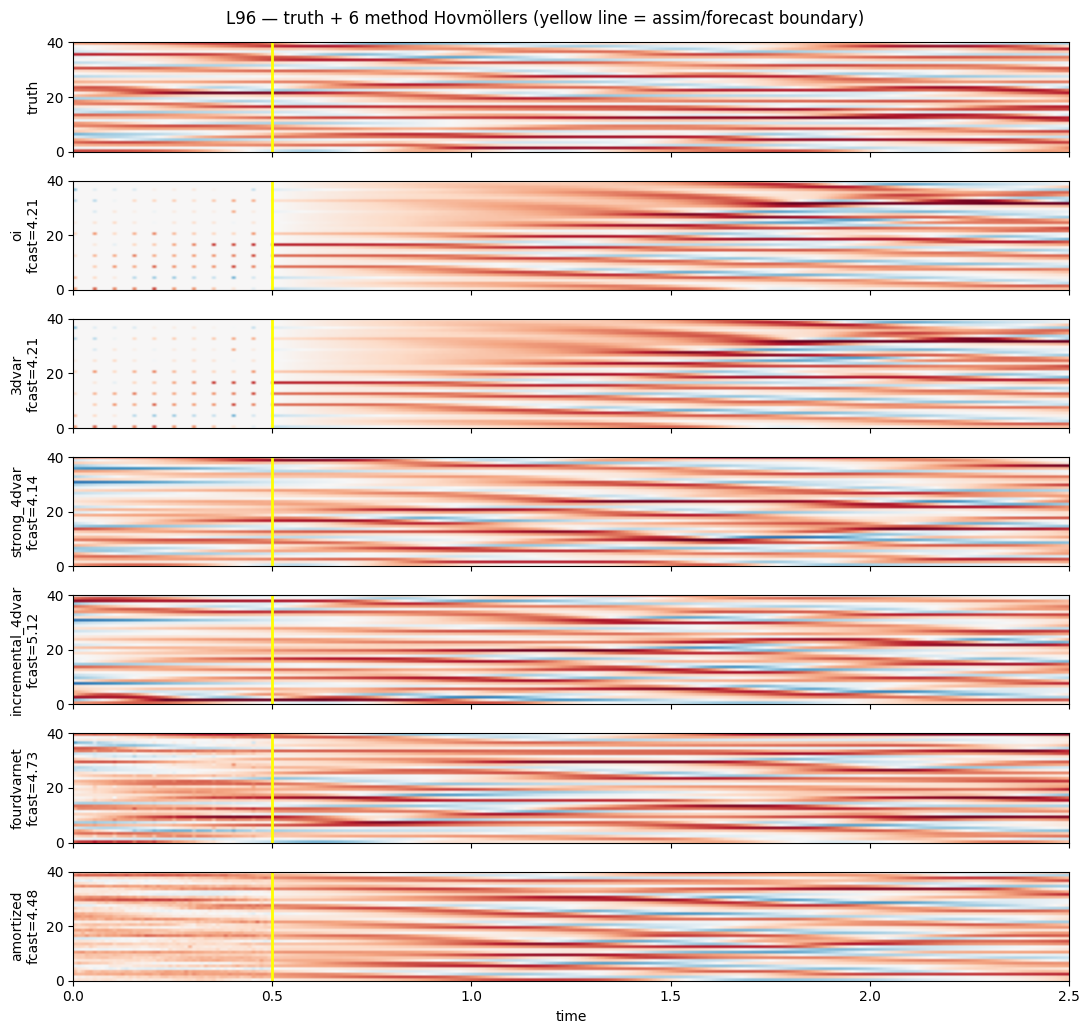

In [6]:
n = len(results)
fig, axs = plt.subplots(1 + n, 1, figsize=(11, 1.5 * (1 + n)), sharex=True)
vmax = float(jnp.max(jnp.abs(prob.truth)))
kwargs = {"aspect": "auto", "cmap": "RdBu_r", "origin": "lower",
          "vmin": -vmax, "vmax": vmax,
          "extent": (0.0, prob.T_total * prob.dt, 0, prob.K)}

axs[0].imshow(prob.truth.T, **kwargs)
axs[0].axvline(prob.T_assim * prob.dt, color="yellow", lw=2)
axs[0].set_ylabel("truth")
for ax, r in zip(axs[1:], results, strict=False):
    ax.imshow(r.mean.T, **kwargs)
    ax.axvline(prob.T_assim * prob.dt, color="yellow", lw=2)
    ax.set_ylabel(f"{r.name}\nfcast={r.rmse_forecast:.2f}")
axs[-1].set_xlabel("time")
fig.suptitle("L96 — truth + 6 method Hovmöllers (yellow line = assim/forecast boundary)")
fig.tight_layout()
plt.show()

## 6. RMSE(t) — the dynamics view

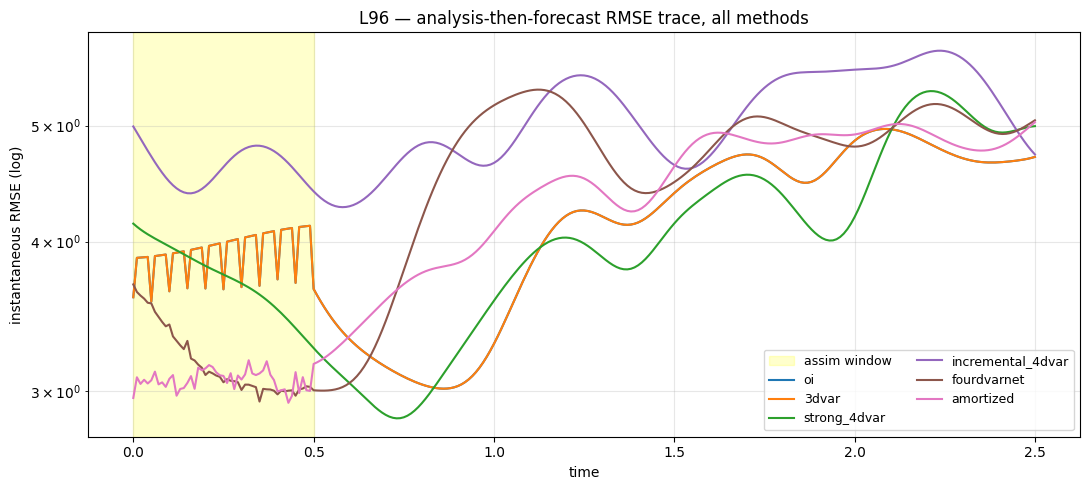

In [7]:
colors = ["C0", "C1", "C2", "C4", "C5", "C6"]
fig, ax = plt.subplots(figsize=(11, 5))
ax.axvspan(0.0, prob.T_assim * prob.dt, color="yellow", alpha=0.2,
           label="assim window")
for r, c in zip(results, colors, strict=False):
    ax.plot(t_axis, r.rmse_trace, color=c, lw=1.5, label=r.name)
ax.set_xlabel("time")
ax.set_ylabel("instantaneous RMSE (log)")
ax.set_yscale("log")
ax.set_title("L96 — analysis-then-forecast RMSE trace, all methods")
ax.grid(True, alpha=0.3, which="both")
ax.legend(loc="best", fontsize=9, ncol=2)
fig.tight_layout()
plt.show()

## 7. Headline numbers

Same story shape as L63 but with the L96 scaling: dynamics-aware
methods produce launch states that hold the forecast for several
Lyapunov times; OI / 3DVar's noisy analyses produce forecasts
that diverge within one Lyapunov time.